In [ ]:
!pip install imbalanced-learn scikit-learn pandas matplotlib

In [3]:
import pandas as pd
import numpy as np

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt

In [4]:
# Create dataset with 95% majority class and 5% minority class
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_classes=2,
    weights=[0.95, 0.05],
    random_state=42
)

df = pd.DataFrame(X)
df["Target"] = y

print(df.head())

print("\nClass Distribution Before SMOTE")
print(df["Target"].value_counts())

          0         1         2         3         4         5         6  \
0  0.964799 -0.066449  0.986768 -0.358079  0.997266  1.181890 -1.615679   
1  1.230350 -0.566395  1.169487  0.831617 -1.176962  1.820544 -1.788927   
2  0.969347 -0.432774  0.858089  0.793818 -0.268646 -1.836360 -1.216083   
3  1.750412  2.023606  1.688159  0.006800 -1.607661  0.184741 -2.619427   
4 -0.001184 -0.711303  0.208114  0.117124  1.536061  0.597538 -0.637329   

          7         8         9  Target  
0 -1.210161 -0.628077  1.227274       0  
1 -0.984534 -1.091341  0.209470       0  
2 -0.246383 -1.066667 -0.297376       0  
3 -0.357445 -1.473127 -0.190039       0  
4 -0.939156  0.684698  0.236224       0  

Class Distribution Before SMOTE
Target
0    947
1     53
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE")
print(pd.Series(y_train).value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
0    759
1     41
Name: count, dtype: int64

After SMOTE
1    759
0    759
Name: count, dtype: int64


In [7]:
model_before = RandomForestClassifier(random_state=42)

model_before.fit(X_train, y_train)

pred_before = model_before.predict(X_test)

print("Accuracy Before SMOTE")
print(accuracy_score(y_test, pred_before))

print(classification_report(y_test, pred_before))

Accuracy Before SMOTE
0.97
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       188
           1       1.00      0.50      0.67        12

    accuracy                           0.97       200
   macro avg       0.98      0.75      0.83       200
weighted avg       0.97      0.97      0.97       200



In [8]:
model_after = RandomForestClassifier(random_state=42)

model_after.fit(X_train_smote, y_train_smote)

pred_after = model_after.predict(X_test)

print("Accuracy After SMOTE")
print(accuracy_score(y_test, pred_after))

print(classification_report(y_test, pred_after))

Accuracy After SMOTE
0.93
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       188
           1       0.44      0.67      0.53        12

    accuracy                           0.93       200
   macro avg       0.71      0.81      0.75       200
weighted avg       0.95      0.93      0.94       200



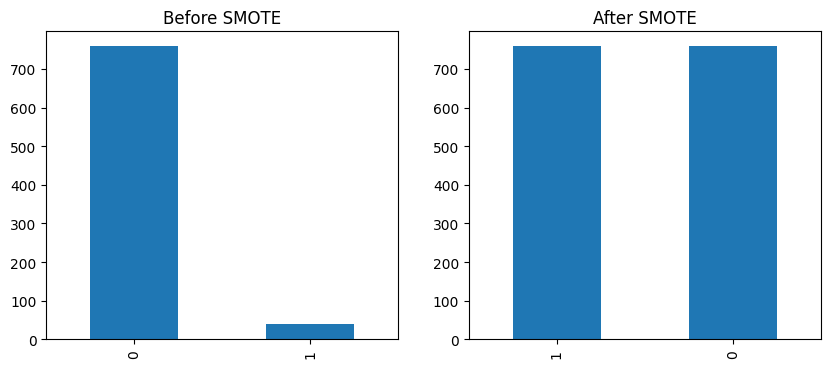

In [9]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

pd.Series(y_train).value_counts().plot(
    kind="bar",
    ax=ax[0],
    title="Before SMOTE"
)

pd.Series(y_train_smote).value_counts().plot(
    kind="bar",
    ax=ax[1],
    title="After SMOTE"
)

plt.show()

In [10]:
assert len(X_train_smote) > len(X_train)

assert len(y_train_smote) == len(X_train_smote)

assert pd.Series(y_train_smote).value_counts()[0] == pd.Series(y_train_smote).value_counts()[1]

print("✅ All tests passed successfully.")

✅ All tests passed successfully.
